# Crude Property — Profiling & Cleaning

**Source:** `Curde Property.xlsx` (raw assay properties feeding the crude unit)

Goal: profile the raw crude assay sheet, keep only rows with real lab values
(the sheet is a template that also carries empty future-date placeholder rows),
and export a clean daily-indexed crude-property table that
`01_data_cleaning.ipynb` will merge onto the process data timeline.

Pipeline:
1. Load & parse raw sheet
2. Drop placeholder rows (no property values)
3. Profile: coverage, missing %, describe()
4. Distribution plots
5. Crude-grade transitions over time (step plot)
6. Export cleaned crude property table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

---
## 1. Load and Parse Data

The sheet has 2 header rows above the real column headers (row index 2), so we
read with `header=2` and rename columns explicitly.

In [2]:
FILEPATH = r'C:\Desktop\Bangchak Internship 2026\Data\Curde Property.xlsx'

raw = pd.read_excel(FILEPATH, sheet_name='Sheet1', header=2)
raw = raw.iloc[:, 1:]  # drop leading empty unnamed column
raw.columns = ['Date', 'API', 'SG_15_6C', 'Visc_50C_cSt', 'Visc_100C_cSt', 'MCRT_pct', 'Asphaltenes_pct']

raw['Date'] = pd.to_datetime(raw['Date'], errors='coerce')
raw = raw.dropna(subset=['Date']).reset_index(drop=True)

print(f'Raw rows (with a date): {len(raw)}')
print(f'Date range: {raw["Date"].min().date()} to {raw["Date"].max().date()}')
raw.head()

Raw rows (with a date): 78792
Date range: 2021-01-01 to 2026-12-24


,Date,API,SG_15_6C,Visc_50C_cSt,Visc_100C_cSt,MCRT_pct,Asphaltenes_pct
0,2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# -- Systematic data-quality gate (shared nb_audit toolkit) --
import nb_audit as A
_ = A.data_quality_report(raw, name='crude raw', show=True)

── Data-quality report: crude raw ──
   rows=78792  cols=7  duplicate_rows=76244
   highest missing %: {'SG_15_6C': 47.5, 'API': 46.9, 'Visc_50C_cSt': 46.9, 'MCRT_pct': 46.9, 'Visc_100C_cSt': 46.9}


---
## 2. Drop Placeholder Rows (No Property Values)

The sheet pre-fills dates through end of 2026 as a template; only rows that
actually carry lab values are real records.

In [4]:
PROPERTY_COLS = ['API', 'SG_15_6C', 'Visc_50C_cSt', 'Visc_100C_cSt', 'MCRT_pct', 'Asphaltenes_pct']

crude = raw.dropna(subset=PROPERTY_COLS, how='all').copy()
crude = crude.drop_duplicates(subset='Date').sort_values('Date').reset_index(drop=True)

n_placeholder = len(raw) - len(crude)
print(f'Rows with real property values: {len(crude)} / {len(raw)} ({n_placeholder} placeholder rows dropped)')
print(f'Date range with real data: {crude["Date"].min().date()} to {crude["Date"].max().date()}')

Rows with real property values: 1876 / 78792 (76916 placeholder rows dropped)
Date range with real data: 2021-04-01 to 2026-06-25


### 2.1 Daily Coverage Check (gaps within the real-data range)

In [5]:
full_range = pd.date_range(crude['Date'].min(), crude['Date'].max(), freq='D')
present = set(crude['Date'])
missing_dates = [d for d in full_range if d not in present]

print(f'Expected daily dates in range: {len(full_range)}')
print(f'Present:                       {len(crude)}')
print(f'Missing within range:          {len(missing_dates)} ({len(missing_dates)/len(full_range)*100:.1f}%)')
if missing_dates:
    print('First missing dates:', [d.date() for d in missing_dates[:10]])

Expected daily dates in range: 1912
Present:                       1876
Missing within range:          36 (1.9%)
First missing dates: [datetime.date(2023, 12, 7), datetime.date(2023, 12, 27), datetime.date(2023, 12, 28), datetime.date(2023, 12, 29), datetime.date(2023, 12, 30), datetime.date(2023, 12, 31), datetime.date(2024, 1, 1), datetime.date(2024, 1, 2), datetime.date(2024, 5, 4), datetime.date(2024, 5, 5)]


---
## 2.2 Outlier / Data-Entry-Error Removal

A block of rows (2024-08-26 to 2024-09-01) has clearly corrupt lab values —
`API=100` (outside any realistic crude range), `SG=NaN`, and `MCRT`/`Asphaltenes`
an order of magnitude above normal (~15% / ~10% vs. typical <1%). This looks
like a data-entry error for that week, not a real crude-grade change.

Flag and drop any row where a property falls outside a physically plausible
range for this crude slate, before profiling/exporting.

In [6]:
PLAUSIBLE_RANGES = {
    'API': (20, 50),
    'SG_15_6C': (0.75, 0.95),
    'Visc_50C_cSt': (0.5, 15),
    'Visc_100C_cSt': (0.3, 8),
    'MCRT_pct': (0, 5),
    'Asphaltenes_pct': (0, 5),
}

outlier_mask = pd.Series(False, index=crude.index)
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    bad = ~crude[col].between(lo, hi) & crude[col].notna()
    if bad.any():
        print(f'{col}: {bad.sum()} row(s) outside [{lo}, {hi}] -> '
              f'{crude.loc[bad, "Date"].dt.date.tolist()}')
    outlier_mask |= bad
# SG missing entirely is also a sign of a corrupt record (SG is mandatory downstream)
outlier_mask |= crude['SG_15_6C'].isna()

n_outliers = outlier_mask.sum()
crude_before = crude.copy()
crude = crude[~outlier_mask].reset_index(drop=True)

print(f'\nDropped {n_outliers} outlier/corrupt row(s) out of {len(crude_before)}')
print(f'Remaining: {len(crude)} rows, {crude["Date"].min().date()} to {crude["Date"].max().date()}')

API: 7 row(s) outside [20, 50] -> [datetime.date(2024, 8, 26), datetime.date(2024, 8, 27), datetime.date(2024, 8, 28), datetime.date(2024, 8, 29), datetime.date(2024, 8, 30), datetime.date(2024, 8, 31), datetime.date(2024, 9, 1)]
Visc_50C_cSt: 7 row(s) outside [0.5, 15] -> [datetime.date(2024, 8, 26), datetime.date(2024, 8, 27), datetime.date(2024, 8, 28), datetime.date(2024, 8, 29), datetime.date(2024, 8, 30), datetime.date(2024, 8, 31), datetime.date(2024, 9, 1)]
Visc_100C_cSt: 5 row(s) outside [0.3, 8] -> [datetime.date(2024, 8, 28), datetime.date(2024, 8, 29), datetime.date(2024, 8, 30), datetime.date(2024, 8, 31), datetime.date(2024, 9, 1)]
MCRT_pct: 7 row(s) outside [0, 5] -> [datetime.date(2024, 8, 26), datetime.date(2024, 8, 27), datetime.date(2024, 8, 28), datetime.date(2024, 8, 29), datetime.date(2024, 8, 30), datetime.date(2024, 8, 31), datetime.date(2024, 9, 1)]
Asphaltenes_pct: 7 row(s) outside [0, 5] -> [datetime.date(2024, 8, 26), datetime.date(2024, 8, 27), datetime.dat

Remaining: 1869 rows, 2021-04-01 to 2026-06-25


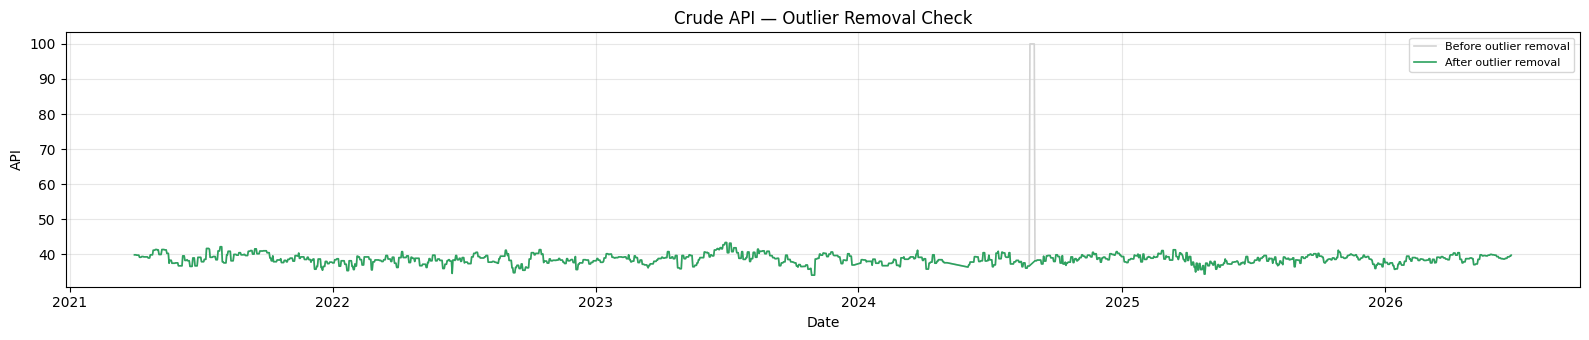

In [7]:
fig, ax = plt.subplots(figsize=(16, 3.5))
ax.plot(crude_before['Date'], crude_before['API'], color='lightgray', linewidth=1.2, label='Before outlier removal')
ax.plot(crude['Date'], crude['API'], color='#2ca25f', linewidth=1.2, label='After outlier removal')
ax.set_ylabel('API')
ax.set_xlabel('Date')
ax.set_title('Crude API — Outlier Removal Check')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Profile Properties

### 3.1 Summary Statistics

In [8]:
crude[PROPERTY_COLS].describe().round(3)

,API,SG_15_6C,Visc_50C_cSt,Visc_100C_cSt,MCRT_pct,Asphaltenes_pct
count,1869.0,1869.000,1869.00,1869.00,1869.00,1869.000
unique,288.0,455.000,394.00,290.00,480.00,502.000
top,39.3,0.831,3.11,1.56,1.02,0.119
freq,48.0,23.000,24.00,47.00,42.00,20.000


### 3.2 Distributions

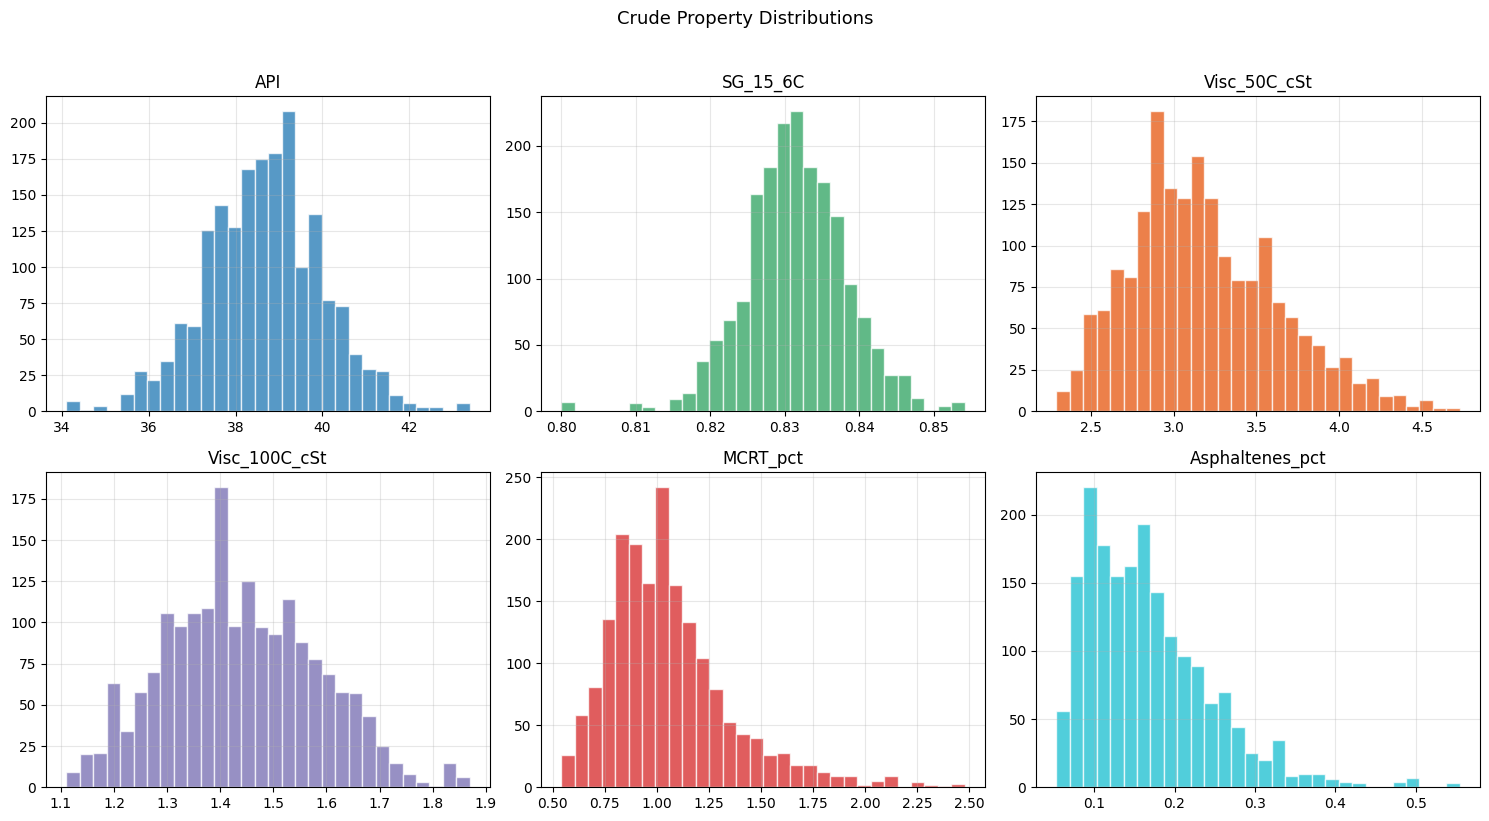

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
colors = ['#1f77b4', '#2ca25f', '#e6550d', '#756bb1', '#d62728', '#17becf']

for ax, col, color in zip(axes, PROPERTY_COLS, colors):
    ax.hist(crude[col].dropna(), bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

fig.suptitle('Crude Property Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Crude Grade Transitions Over Time

Properties change in step-blocks (crude grade switches), not continuously —
visualize as step plots.

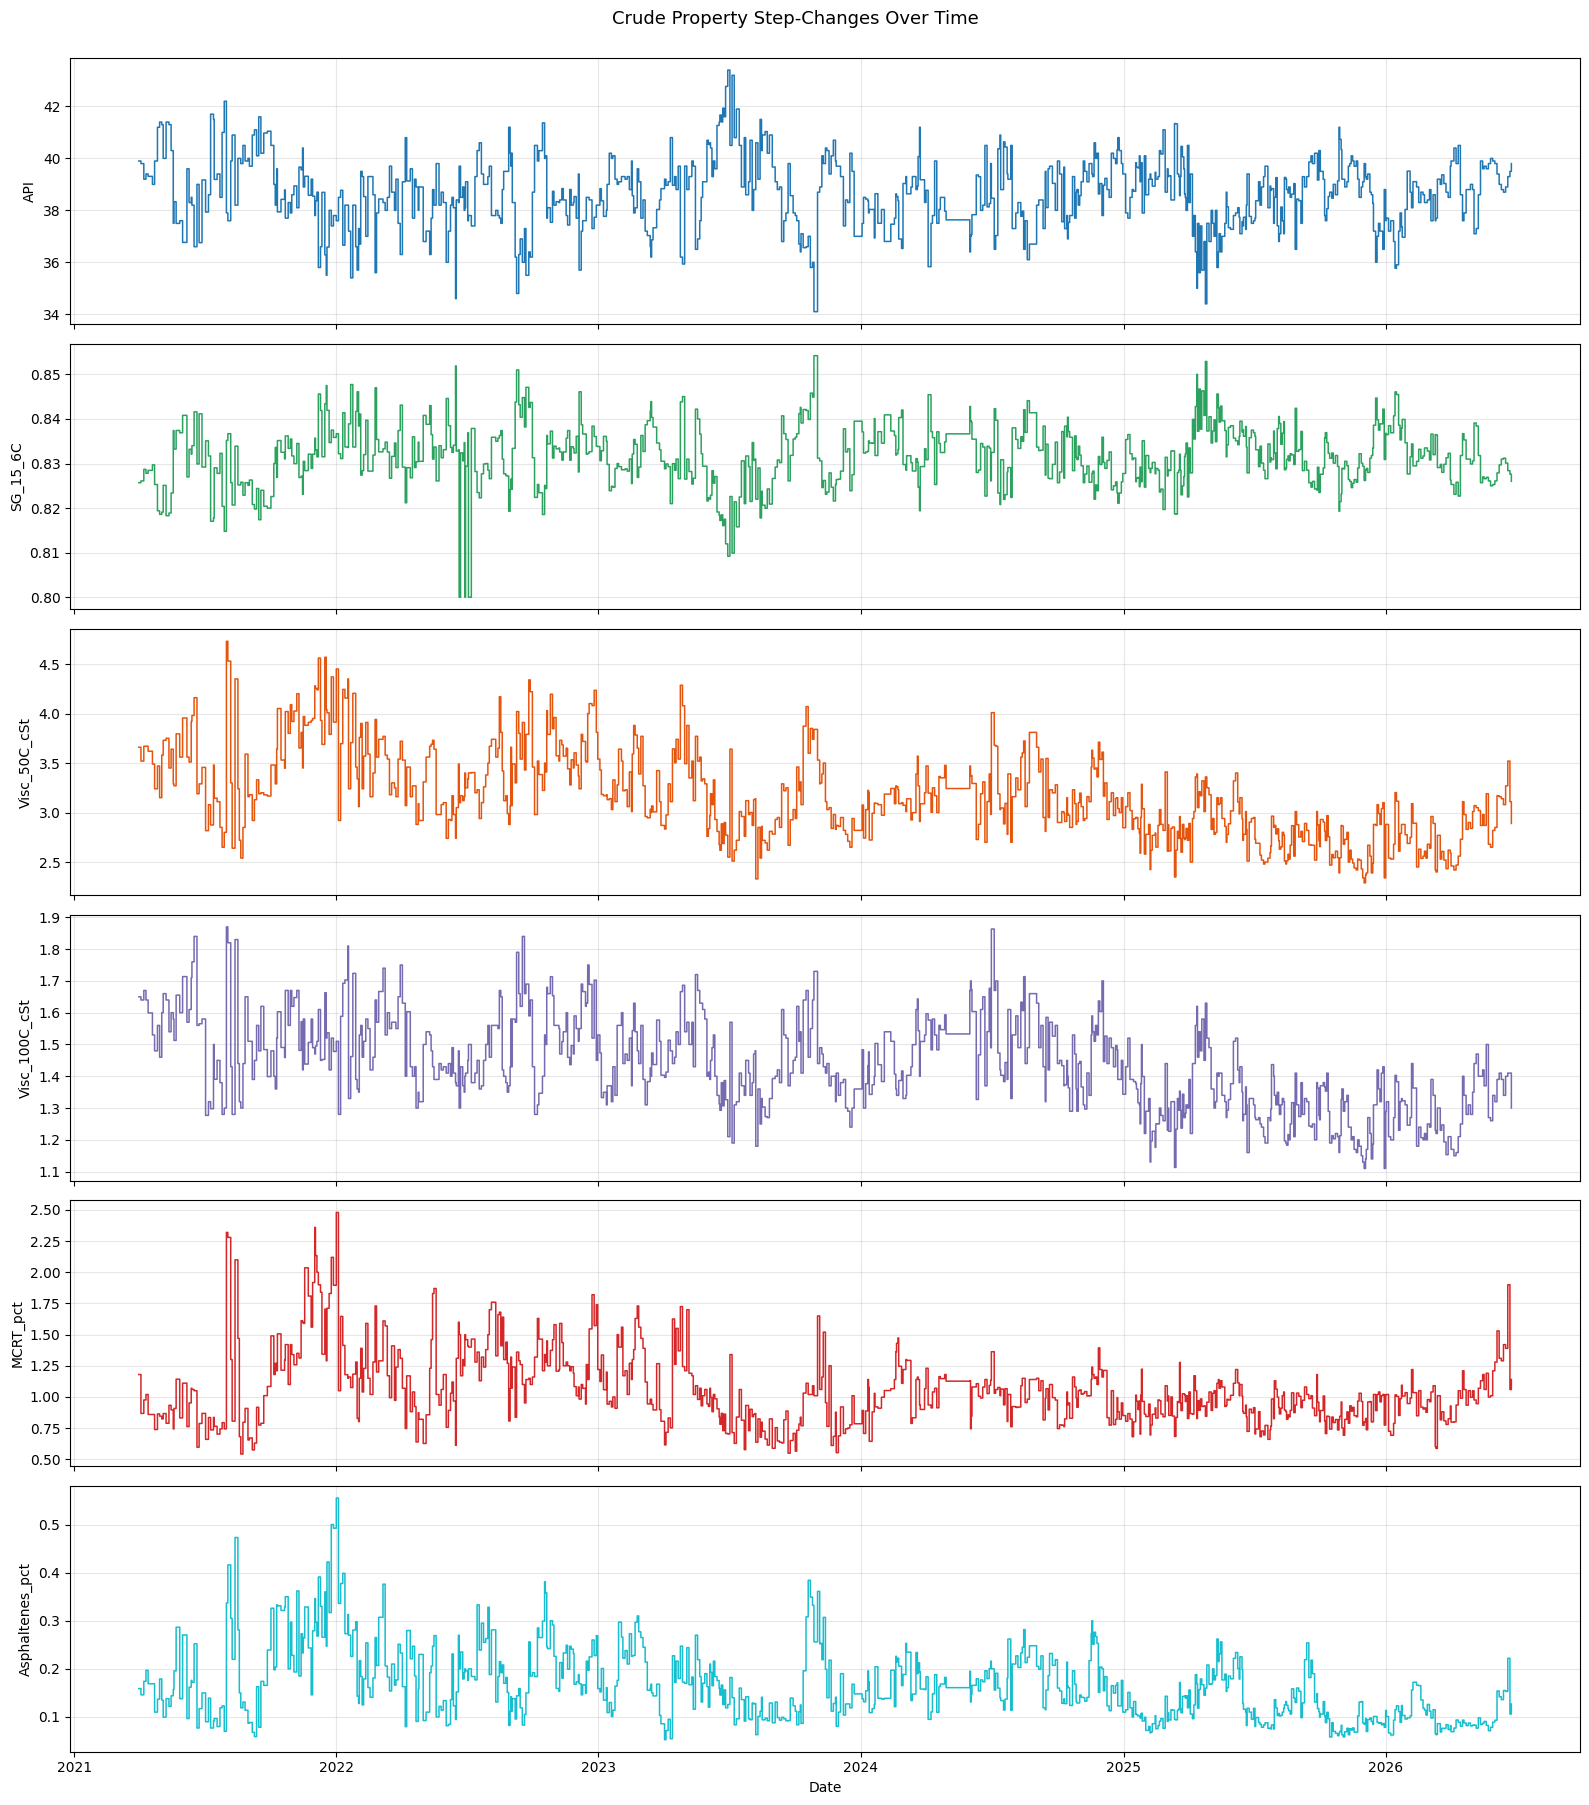

In [10]:
fig, axes = plt.subplots(len(PROPERTY_COLS), 1, figsize=(16, 3 * len(PROPERTY_COLS)), sharex=True)

for ax, col, color in zip(axes, PROPERTY_COLS, colors):
    ax.step(crude['Date'], crude[col], where='post', color=color, linewidth=1.1)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Crude Property Step-Changes Over Time', fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

---
## 5. Export Cleaned Crude Property Table

Saved with only the real (non-placeholder) daily records. Gap-filling onto the
full process-data timeline (including forward-fill beyond the last known date)
happens downstream in `01_data_cleaning.ipynb`.

In [11]:
OUTPUT_PATH = r'C:\Desktop\Bangchak Internship 2026\Data\Crude_property_profiled.csv'

crude_export = crude.set_index('Date')
crude_export.to_csv(OUTPUT_PATH)

print(f'Saved to: {OUTPUT_PATH}')
print(f'Shape: {crude_export.shape}')
print(f'Date range: {crude_export.index.min().date()} to {crude_export.index.max().date()}')

Saved to: C:\Desktop\Bangchak Internship 2026\Data\Crude_property_profiled.csv
Shape: (1869, 6)
Date range: 2021-04-01 to 2026-06-25
